# CROSS-VALIDATION Clustered Random Forest

In [2]:
import mod_loading as loader
from importlib import reload
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime
from tqdm import tqdm

from datetime import datetime
import gsw
import mod_argo
import matplotlib.pyplot as plt
from cmocean import cm as cmo

import mod_regression as mod_reg
import mod_preprocessing as mod_prep
reload(mod_reg)

<module 'mod_regression' from '/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/src/mod_regression.py'>

In [3]:
datetag = datetime.now().strftime('%Y%m%d')

# 1.0 Setup data

In [91]:
reload(loader)

# ==== choose data run parameters
float_carbon_var= 'pHbias5_pK1'
pcm_params='pc8_gmm6'
n_gmm = int(pcm_params.split('_')[1][-1])
desc = 'floatparam_' + float_carbon_var + '_' + pcm_params
print(desc + '; ' + datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
# ===== import 

# Import
reload(loader)
[floatDF, shipDF] =  loader.import_preprocessed_inputs(pcm_params=pcm_params, float_param = float_carbon_var)
# [floatDF, shipDF] =  loader.import_processed_inputs(float_param = float_carbon_var)
len(floatDF), len(shipDF)


floatparam_pHbias5_pK1_pc8_gmm6; 2026-02-11 09:18:20


(11177, 6080)

In [82]:
# == IMPORT from 3.1

# folder = '../working-vars/regression/trainval-splits/'
# use_datetag = '20260206'

# trainDF = pd.read_csv('trainDF_allplat_floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4_acc'+ use_datetag + '.csv', index_col=0)
# valDF = pd.read_csv('valDF_allplat_floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4_acc'+ use_datetag + '.csv', index_col=0)




# 2.0 Subsetting training/validation using GMM probabilities

In [92]:
reload(mod_reg)
reload(loader)

# Add clustering probabilities to the float DF
# allprobs returns probabilities by profid for each class
[Y_gmm, allprobs, gmm_desc, coreDF] = loader.import_clustering_results(pcm_params = pcm_params)

finder = allprobs.set_index('profid') # temp object to search
if '0' in finder.columns:
   finder = finder.rename(columns = {str(k): k+1 for k in np.arange(n_gmm-1, -1, -1)})
# print(finder.columns)
for k in range(1, n_gmm+1):
    floatDF['class' + str(k) + '_prob'] = floatDF['profid'].apply(lambda x: finder.loc[x, k] if x in finder.index else np.nan)
    shipDF['class' + str(k) + '_prob'] = shipDF['nearest_profid'].apply(lambda x: finder.loc[x, k] if x in finder.index else np.nan)

# [Y_gmm, allprobs, gmm_desc, coreDF] = loader.import_clustering_results(pcm_params = pcm_params)

## K FOLD -

In [ ]:
# # ====== outdated K FOLD VERSION - new object CrossValContainer in mod_regression.py
# # updated feb 2026
# nfolds = 5
# platDF_all = pd.concat([floatDF, shipDF], axis=0)

# cv_container = {('fold'+str(k)): {'trainClasses':{k:None for k in range(1, n_gmm+1)}, 
#                                          'valClasses':{k:None for k in range(1, n_gmm+1)}, 
#                                          'trainDF_all': None,
#                                          'valDF_all':None,
#                                          'countobs':None} for k in range(1, nfolds+1)}

# for soclass in range(1, n_gmm+1):
#     # print('==> Processing class ' + str(soclass))
#     classDF = platDF_all[platDF_all['cluster'] == soclass]
#     [classDF_float, classDF_ship] = mod_reg.separate_platforms(classDF)

#     # trainfolds_float is a dictionary, keys are 'fold1' holding one class's training data
#     [trainfolds_float, valfolds_float] = mod_reg.subset_folds(classDF_float, indexer='wmoid', nfolds=nfolds)
#     [trainfolds_ship, valfolds_ship] = mod_reg.subset_folds(classDF_ship, indexer='cruiseid', nfolds=nfolds)

#     for nfold in range(1, nfolds+1):
#         # split up the data for this southern ocean class, fill in for each fold
#         foldtag = 'fold' + str(nfold)
#         foldtrain_soclass = pd.concat([trainfolds_float[foldtag], trainfolds_ship[foldtag]], axis=0)
#         foldval_soclass =  pd.concat([valfolds_float[foldtag], valfolds_ship[foldtag]], axis=0)
#         cv_container[foldtag]['trainClasses'][soclass] = foldtrain_soclass.copy() # dataframe for this class, this fold
#         cv_container[foldtag]['valClasses'][soclass] = foldval_soclass.copy()

# # After separating class data into respective folds, check train/val counts by class
# for nfold in range(1, nfolds+1):
#     foldtag = 'fold' + str(nfold)
#     cv_container[foldtag]['countobs'] = mod_reg.get_trainval_counts(cv_container[foldtag]['trainClasses'], cv_container[foldtag]['valClasses'], n_gmm=n_gmm)
#     cv_container[foldtag]['trainDF_all'] = pd.concat(cv_container[foldtag]['trainClasses'].values(), axis=0)
#     # in practice we use weighted ave so valClasses not really necessary
#     cv_container[foldtag]['valDF_all'] = pd.concat(cv_container[foldtag]['valClasses'].values(), axis=0) 

In [20]:
# # # ====== outdated K FOLD VERSION - new object CrossValContainer in mod_regression.py
# Option to remove sea ice zone from these classes, for all folds

# cv_container_final = cv_container.copy()
# exclude_nums = [4] # gmm6=[4], gmm8=[3]

# for nfold in range(1, nfolds+1):
#     foldtag = 'fold' + str(nfold)
#     trainClasses = cv_container_final[foldtag]['trainClasses']
#     valClasses = cv_container_final[foldtag]['valClasses']
#     [cv_container_final[foldtag]['trainClasses'], 
#         cv_container_final[foldtag]['valClasses'],  
#         cv_container_final[foldtag]['trainDF_all'], 
#         cv_container_final[foldtag]['valDF_all']] = mod_reg.exclude_classes(exclude_nums, 
#                                                             trainClasses, valClasses, 
#                                                             n_gmm=n_gmm,
#                                                             reassign_numbers=True)
#     cv_container_final[foldtag]['countobs'] = mod_reg.get_trainval_counts(cv_container_final[foldtag]['trainClasses'], 
#                                                                              cv_container_final[foldtag]['valClasses'], 
#                                                                              n_gmm=n_gmm-len(exclude_nums))

[1, 2, 3, 5, 6]
[1, 2, 3, 5, 6]
[1, 2, 3, 5, 6]
[1, 2, 3, 5, 6]
[1, 2, 3, 5, 6]


In [75]:
for nfold in range(1, nfolds+1):
    print('===> Observation counts for fold ' + str(nfold))
#     countobs = mod_reg.get_trainval_counts(cv_container_final[foldtag]['trainClasses'], folds_container[foldtag]['valClasses'], n_gmm=n_gmm-len(exclude_nums))
    print(cv_container_final[foldtag]['countobs'] )

===> Observation counts for fold 1


NameError: name 'cv_container_final' is not defined

## Trying with new object version - updated feb 6 2026

In [93]:
# MAIN RUN FEB 6 2026

nfolds = 5
platDF_all = pd.concat([floatDF, shipDF], axis=0)

cvtainer = mod_reg.CrossValContainer(fold_list = ['fold' + str(k) for k in range(1, nfolds+1)], n_clusters = n_gmm)

##### 
# cvtainer = {('fold'+str(k)): {'trainClasses':{k:None for k in range(1, n_gmm+1)}, 
#                                          'valClasses':{k:None for k in range(1, n_gmm+1)}, 
#                                          'trainDF_all': None,
#                                          'valDF_all':None,
#                                          'countobs':None} for k in range(1, nfolds+1)}

for soclass in range(1, n_gmm+1):
    # print('==> Processing class ' + str(soclass))
    classDF = platDF_all[platDF_all['cluster'] == soclass]
    [classDF_float, classDF_ship] = mod_reg.separate_platforms(classDF)

    # trainfolds_float is a dictionary, keys are 'fold1' holding one class's training data
    [trainfolds_float, valfolds_float] = mod_reg.subset_folds(classDF_float, indexer='wmoid', nfolds=nfolds)
    [trainfolds_ship, valfolds_ship] = mod_reg.subset_folds(classDF_ship, indexer='cruiseid', nfolds=nfolds)

    for nfold in range(1, nfolds+1):
        # split up the data for this southern ocean class, fill in for each fold
        foldtag = 'fold' + str(nfold)
        foldtrain_soclass = pd.concat([trainfolds_float[foldtag], trainfolds_ship[foldtag]], axis=0)
        foldval_soclass =  pd.concat([valfolds_float[foldtag], valfolds_ship[foldtag]], axis=0)


        cvtainer.trainClasses[foldtag][soclass] =  foldtrain_soclass.copy()
        cvtainer.valClasses[foldtag][soclass] =  foldval_soclass.copy()

# After separating class data into respective folds, check train/val counts by class
for nfold in range(1, nfolds+1):
    foldtag = 'fold' + str(nfold)
    
    cvtainer.countobs[foldtag] = mod_reg.get_trainval_counts(cvtainer.trainClasses[foldtag], cvtainer.valClasses[foldtag], n_gmm=n_gmm)
    cvtainer.trainDF_all[foldtag] = pd.concat(cvtainer.trainClasses[foldtag].values(), axis=0)
    cvtainer.valDF_all[foldtag] = pd.concat(cvtainer.valClasses[foldtag].values(), axis=0)



In [94]:
# Option to remove sea ice zone from these classes, for all folds
exclude_nums = [4] # gmm6=[4], gmm8=[3]
n_clusters = n_gmm - len(exclude_nums) 
cvtainer_final = mod_reg.CrossValContainer(fold_list = ['fold' + str(k) for k in range(1, nfolds+1)], 
                                               n_clusters = n_clusters)

for nfold in range(1, nfolds+1):
    foldtag = 'fold' + str(nfold)
    trainClasses = cvtainer.trainClasses[foldtag]
    valClasses = cvtainer.valClasses[foldtag]

    [cvtainer_final.trainClasses[foldtag], 
     cvtainer_final.trainDF_all[foldtag]] = mod_reg.exclude_classes(exclude_nums, 
                                                            trainClasses, n_gmm=n_gmm, reassign_numbers=True)
    [cvtainer_final.valClasses[foldtag], 
     cvtainer_final.valDF_all[foldtag]] = mod_reg.exclude_classes(exclude_nums, 
                                                            valClasses, n_gmm=n_gmm, reassign_numbers=True)

    cvtainer_final.countobs[foldtag] = mod_reg.get_trainval_counts(cvtainer_final.trainClasses[foldtag], 
                                                                             cvtainer_final.valClasses[foldtag], 
                                                                             n_gmm=n_clusters)




In [10]:
cvtainer_final.countobs['fold3']

,train,validation,train_float,train_ship,val_float,val_ship,train_pc_float,val_pc_float,TOTAL_FLOAT,TOTAL_SHIP,TOTAL_OBS
cluster,,,,,,,,,,,
1,2743,228,769,1974,113,115,28.034998,49.561404,882,2089,2971
2,2479,756,1814,665,568,188,73.174667,75.132275,2382,853,3235
3,1631,337,1364,267,255,82,83.629675,75.667656,1619,349,1968
4,1616,355,712,904,173,182,44.059406,48.732394,885,1086,1971
5,2154,517,1742,412,416,101,80.872795,80.464217,2158,513,2671


In [11]:
# Also add single platform dictionaries to the CrossValContainer object
for fold in cvtainer_final.fold_list:
    vdat_combined = cvtainer_final.valDF_all[fold] 
    [vdat_float, vdat_ship] = mod_reg.separate_platforms(vdat_combined)
    cvtainer_final.valClasses_float[fold] = {int(ncluster):df for ncluster, df in vdat_float.groupby('cluster')}
    cvtainer_final.valClasses_ship[fold] = {int(ncluster):df for ncluster, df in vdat_ship.groupby('cluster')}

    tdat_combined = cvtainer_final.trainDF_all[fold] 
    [tdat_float, tdat_ship] = mod_reg.separate_platforms(tdat_combined)
    cvtainer_final.trainClasses_float[fold] = {int(ncluster):df for ncluster, df in tdat_float.groupby('cluster')}
    cvtainer_final.trainClasses_ship[fold] = {int(ncluster):df for ncluster, df in tdat_ship.groupby('cluster')}


In [12]:
# ======= Adjust description and ds
desc = 'floatparam_' + float_carbon_var + '_' + pcm_params

if len(exclude_nums) > 0:
    desc = desc + '_excludeClass' + str(exclude_nums[0])
    print('New description tag with excluded class: ' + desc)


New description tag with excluded class: floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4


# Plots

In [13]:
datatype_colors = {'train' : "#332288", 
                   'validation' :  "#ED7F1E", 
                   'combined' : "#524F4F",
                   'train_comb':  "#332288", 
                   'val_comb':  "#6EC3EE", 
                   'train_float': "#882255",  # rose
                   'val_float': "#DDCC77",  # rose
                   'train_ship': "#44AA99",  # dark blue
                   'val_ship': "#CC6677",  # dark blue
                   }

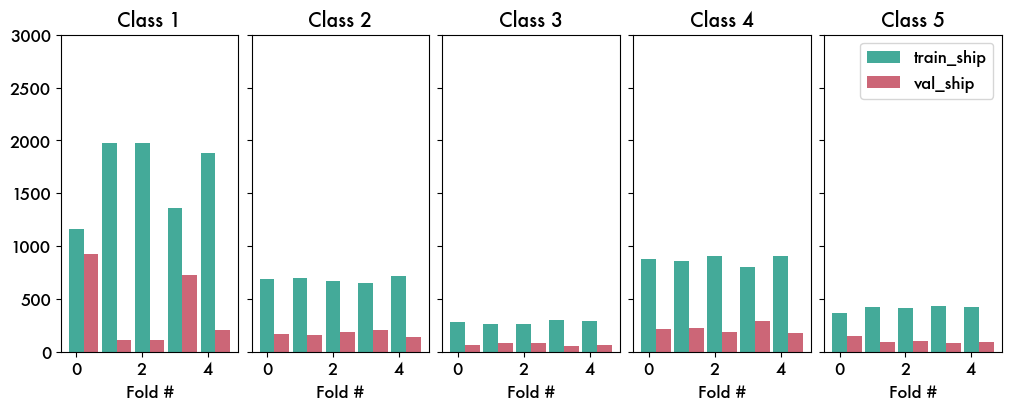

In [14]:
# VISUALIZE TRAIN/VAL COUNTS BY FOLD, BY CLASS
# === choose which data to restrict to 
# plat_type = 'comb' 
# plat_type = '_float'
plat_type = '_ship'

trainvar = 'train'; valvar = 'validation'
if plat_type in ['_float', '_ship']:
    trainvar += plat_type; valvar = valvar[:3] + plat_type

n_clusters = n_gmm - len(exclude_nums)
list_folds = ['fold'+str(k) for k in range(1, nfolds+1)]


# === plot 
fig, axs = plt.subplots(1, n_clusters, figsize=(2*n_clusters, 4), sharey='row', layout='constrained')

for ncluster in range(1,n_clusters+1):
    plot_data = {
        trainvar: [cvtainer_final.countobs[ftag].loc[ncluster, trainvar] for ftag in list_folds],
        valvar: [cvtainer_final.countobs[ftag].loc[ncluster, valvar] for ftag in list_folds],
    }

    x = np.arange(len(list_folds))  # the label locations
    width = 0.45  # the width of the bars
    multiplier = 0

    # fig, ax = plt.subplots(layout='constrained')

    ax = axs[ncluster-1]

    for subset_type, nobs in plot_data.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, nobs, width, label=subset_type, color=datatype_colors[subset_type])
        # ax.bar_label(rects, padding=3)
        multiplier += 1

    # ax.set_xticks(x + width, list_folds)
    ax.set_xlabel('Fold #')
    ax.set_title('Class ' + str(ncluster))

for ax in axs.flatten():
    ax.set_ylim(0,3000)
    # ax.legend(loc='upper left', ncols=3)

ax.legend()

In [15]:
import figs_pcm

# Train RFR

In [16]:
# =========  Updated Jan 2026 run parameters ========= 
# Set run parameters and feature lists
reload(mod_reg)
print(desc)
feat_lists = [['CT', 'SA', 'mld'], #log(MLD) taken within the fit_single_RFR function
            ['CT', 'SA', 'mld', 'ydcos', 'ydsin'],
            ['CT', 'SA', 'mld', 'adt'],
            ['CT', 'SA', 'mld', 'adt', 'ydcos', 'ydsin'],
            # ['CT', 'SA', 'mld', 'sla'],
            # ['CT', 'SA', 'mld', 'sla', 'ydcos', 'ydsin'],
            # ['CT', 'SA', 'mld', 'adt', 'sla'],
            # ['CT', 'SA', 'mld', 'adt', 'sla', 'ydcos', 'ydsin']
            ]
feat_options = mod_reg.make_feat_dict(feat_lists)

# Choose trained on ship, float, or combined
# Always validate on same set of samples
# consistent_valDF = pd.concat(cvtainer_final.valDF_all.values(), axis=0) # full length of training
data_options = {'float': [cvtainer_final.trainClasses_float, cvtainer_final.valDF_all], #validationClasses
                'ship': [cvtainer_final.trainClasses_ship, cvtainer_final.valDF_all],
                'combined': [cvtainer_final.trainClasses, cvtainer_final.valDF_all]}

# Regression target variables
target_options = ['delta_pco2'] #, 'pco2']

# =========== Automatically generate run tag combinations
run_tags = mod_reg.make_run_tags(feat_options, data_options, target_options)

# ========= Set up hyperparameters ========= 
ntrees = 1000
max_feats = 1/3
min_samples_split = 5

floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4


In [ ]:
# Initiailize object
# COMMENT OUT IF YOU WANT TO KEEP OLD RUNS
# storedCV = {run_tag:{nfold:None for nfold in cvtainer_final.fold_list} for run_tag in run_tags}

In [20]:
# == MAIN TRAINING FOR CROSS-VALIDATION 
print('===> Training RFR (' + desc + ') ' +datetime.now().strftime('%Y-%m-%d %H:%M:%S') )

for run_tag in tqdm(run_tags[:]):
    feat_key = run_tag.split('-')[0]
    dataset_key = run_tag.split('-')[1]
    var_predict = run_tag.split('-')[2]

    valdict_byFold = data_options[dataset_key][1].copy() # holds dfs
    traindict_byFold = data_options[dataset_key][0] # holds dicts

    # move here to below into mod_reg
    nclusters = n_gmm - len(exclude_nums)
    k_list = range(1,nclusters+1) # Number of clusters
    feat_list = feat_options[feat_key]

    # === TRAINING
    for nfold in cvtainer_final.fold_list:    # separate for each fold, same run tag
        RFR_clustered = mod_reg.ClusteredModelVersion(ind_list = k_list, feat_list = feat_list) #singleRun

        fold_traindict_byClass = traindict_byFold[nfold] # dictionary keyed by cluster, holding dataframes
        fold_trainDF = pd.concat(fold_traindict_byClass.values())
        fold_valDF = valdict_byFold[nfold] 

        for k in k_list: 
            trainingDF_class = fold_traindict_byClass[k] # new training dictionary for each kfold / class
            RFR_clustered.models[k] = mod_reg.fit_single_RFR(feat_list, 
                                    trainingDF_class, 
                                    var_predict = var_predict, 
                                    loss_criterion = 'squared_error',
                                    ntrees = ntrees, max_feats = max_feats,
                                    min_samples_split=min_samples_split)

        # === VALIDATION ERRORS (and training errors for calibration)
        
        RFR_clustered.weighted_training = mod_reg.apply_cluster_RFR(feat_list, RFR_clustered, fold_trainDF, sample_tag='train')
        RFR_clustered.weighted_validation = mod_reg.apply_cluster_RFR(feat_list, RFR_clustered, fold_valDF, sample_tag='val')

        storedCV[run_tag][nfold] = RFR_clustered

===> Training RFR (floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4) 2026-02-10 08:56:13


100%|██████████| 12/12 [07:09<00:00, 35.78s/it]


In [24]:
#  ==========  Collapse errors across folds so you can treat as storedRuns for comparison and visualization functions

storedCV_collapsed = {run_tag: None for run_tag in run_tags}
k_list = range(1, n_clusters+1) # Number of clusters

for run_tag in run_tags[:]:
    # make temp obj so you can run mod_Reg functions on it like a normal ClusteredModelVersion object, 
    # collapse across folds
    tempRun = mod_reg.ClusteredModelVersion(ind_list = k_list)
    singleRun_errors_across_folds = pd.DataFrame()

    for nfold in cvtainer_final.fold_list:
        tempDF = storedCV[run_tag][nfold].weighted_validation
        tempDF['fold'] = np.tile(nfold, len(tempDF))
        singleRun_errors_across_folds = pd.concat([singleRun_errors_across_folds, tempDF], axis=0)

    # storedCV_collapsed[run_tag] = singleRun_errors_across_folds
    tempRun.weighted_validation = singleRun_errors_across_folds
    storedCV_collapsed[run_tag] = tempRun

# ========== Collapse errors into lists for each runtag to compare and plot 
runtag_errors = {rt:[mod_reg.summarize_DF_errors(storedCV[rt][use_fold].weighted_validation)[0] 
                     for use_fold in cvtainer_final.fold_list] 
                     for rt in run_tags}

In [25]:
# ==== Compare performance across different clustered-rfr runs

print(desc)

# storedRuns_summary = mod_reg.storedRuns_comparison(storedRuns_gmm8_ex3_MAE) # exclude class 4
use_fold = 'fold2'
storedCV_onefold = {run_tag:storedCV[run_tag][use_fold] for run_tag in run_tags}
storedRuns_summary = mod_reg.storedRuns_comparison(storedCV_onefold, run_tags[:]) # exclude class 4

# Choose which type of run to show
show_rows = [x for x in run_tags if 'combined' in x]
# show_rows = storedRuns_summary.index.tolist()

# Choose order
storedRuns_summary.loc[show_rows]
storedRuns_summary.loc[show_rows].sort_values('median_AE')

floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4


,median_AE,mean_AE,bias,RMSE
featD-combined-delta_pco2,10.875032,14.656090,-1.016492,19.609769
featB-combined-delta_pco2,11.300838,14.995077,-0.745970,20.048721
featA-combined-delta_pco2,11.501488,15.240819,-1.176528,20.286570
featC-combined-delta_pco2,11.714735,15.223329,-1.654732,20.102267


/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_28684/4165384331.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(which_tags, rotation=45, ha='right')


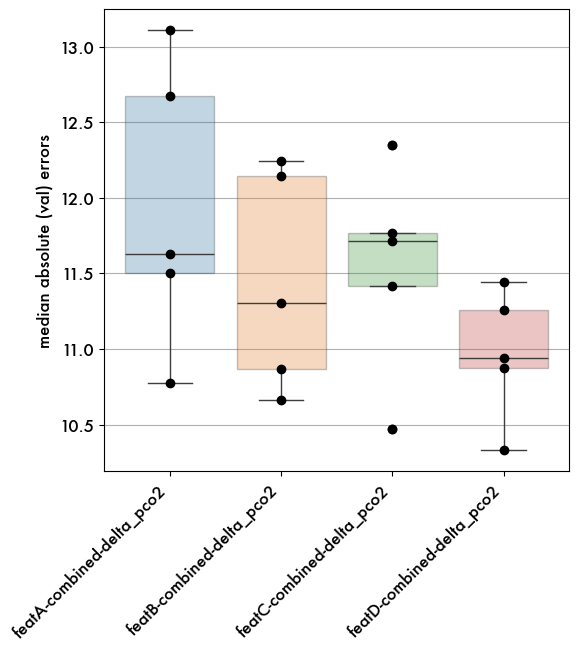

In [26]:
import seaborn as sns 

# type='_'
type = 'combined' 
# type = 'float' 
# type = 'ship'

which_tags = [rt for rt in run_tags if type in rt]

runtag_errors = {rt:[mod_reg.summarize_DF_errors(storedCV[rt][use_fold].weighted_validation)[0] 
                     for use_fold in cvtainer_final.fold_list] 
                     for rt in run_tags}

plt_data = {k:dat for k, dat in runtag_errors.items() if k in which_tags}

fig = plt.figure(figsize=(len(plt_data.keys())*1.5,6))
ax = fig.gca()


sns.boxplot(data=plt_data, ax=ax, boxprops={'alpha':0.3}, zorder=2)
# ax.boxplot(data=plt_data, zorder=2)

for ind, k in enumerate(plt_data.keys()):
    ax.scatter(np.tile(ind, len(plt_data[k])), plt_data[k], color='k', label=k, zorder=5)
# ax.scatter(storedRuns_summary.index, storedRuns_summary.median_AE, label=use_fold)

# ax scatter()
ax.set_xticklabels(which_tags, rotation=45, ha='right')
ax.set_ylabel('median absolute (val) errors' )
ax.grid(axis='y')

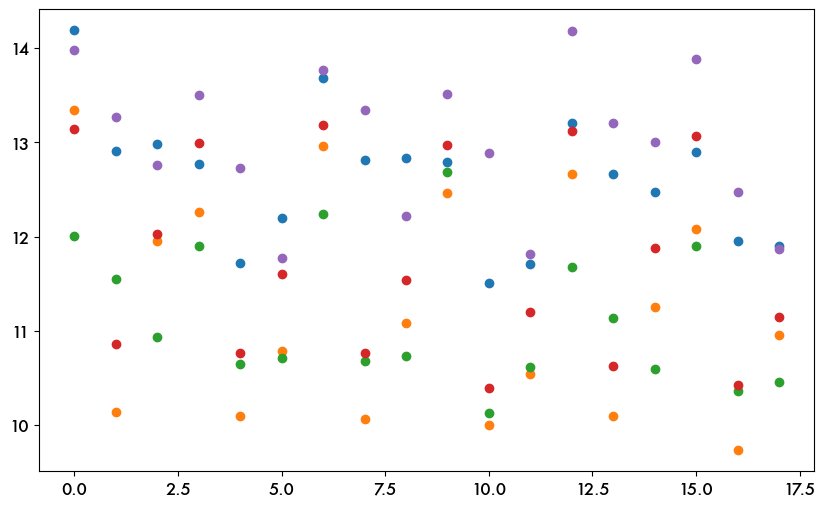

In [188]:
fig = plt.figure(figsize=(10,6))
ax = fig.gca()

use_fold = 'fold2'
for use_fold in cvtainer_final.fold_list:
    storedCV_onefold = {run_tag:storedCV[run_tag][use_fold] for run_tag in run_tags}
    storedRuns_summary = mod_reg.storedRuns_comparison(storedCV_onefold, run_tags[:]).reset_index() 

    ax.scatter(storedRuns_summary.index, storedRuns_summary.median_AE, label=use_fold)




In [27]:
# ==== COMPARE ERRORS FOR RUN TAGS, COMBINED ACROSS FOLDS
print(desc)

# storedRuns_summary = mod_reg.storedRuns_comparison(storedRuns_gmm8_ex3_MAE) # exclude class 4
storedRuns_summary = mod_reg.storedRuns_comparison(storedCV_collapsed, run_tags[:]) # exclude class 4

# Choose which type of run to show
show_rows = [x for x in run_tags if 'combined' in x]
# show_rows = storedRuns_summary.index.tolist()

# Choose order
storedRuns_summary.loc[show_rows]
storedRuns_summary.loc[show_rows].sort_values('median_AE')

floatparam_pHbias5_pK1_pc8_gmm6_excludeClass4


,median_AE,mean_AE,bias,RMSE
featD-combined-delta_pco2,10.886667,14.974859,0.376727,21.013160
featB-combined-delta_pco2,11.304051,15.242426,0.217340,21.213515
featC-combined-delta_pco2,11.414551,15.579657,0.135825,21.631899
featA-combined-delta_pco2,11.809820,15.858994,0.094280,21.830544


# Fit calibration for each class using OOF errors

In [28]:
storedCV_collapsed # collapsed across folds 

{'featA-float-delta_pco2': <mod_regression.ClusteredModelVersion at 0x7e164f130>,
 'featA-ship-delta_pco2': <mod_regression.ClusteredModelVersion at 0x7a792e2e0>,
 'featA-combined-delta_pco2': <mod_regression.ClusteredModelVersion at 0x347d59e20>,
 'featB-float-delta_pco2': <mod_regression.ClusteredModelVersion at 0x6571fefa0>,
 'featB-ship-delta_pco2': <mod_regression.ClusteredModelVersion at 0x33d1ffdf0>,
 'featB-combined-delta_pco2': <mod_regression.ClusteredModelVersion at 0x50e37d070>,
 'featC-float-delta_pco2': <mod_regression.ClusteredModelVersion at 0x33d07e280>,
 'featC-ship-delta_pco2': <mod_regression.ClusteredModelVersion at 0x479b90040>,
 'featC-combined-delta_pco2': <mod_regression.ClusteredModelVersion at 0x3dfa3a700>,
 'featD-float-delta_pco2': <mod_regression.ClusteredModelVersion at 0x3dfa09ac0>,
 'featD-ship-delta_pco2': <mod_regression.ClusteredModelVersion at 0x548e2cb50>,
 'featD-combined-delta_pco2': <mod_regression.ClusteredModelVersion at 0x7a790ee20>}

In [29]:
# ========== Collapse errors into lists for each runtag to compare and plot 
runtag_errors = {rt:[mod_reg.summarize_DF_errors(storedCV[rt][use_fold].weighted_validation)[0] 
                     for use_fold in cvtainer_final.fold_list] 
                     for rt in run_tags}

In [31]:
import figs_regression as figs_reg
import scipy.stats as stats

In [372]:
singleModel_valDF

,profid,wmoid,prof_datetag,cluster,datetime,latitude,longitude,linear_time,ydcos,ydsin,...,class4_pred,class5_pred,weighted_pred,val_error,val_relative_error,fold,val_error_sq,ape,lincal_pred,n_decile
2842,5904675_id021,5904675.0,5904675_20160807,1,2016-08-07 05:21:59.999995,-41.379000,95.86900,949.223611,-0.813307,-0.581835,...,-18.744220,-29.474465,-24.975009,-16.045116,1.456619,fold1,257.445745,145.661881,-27.438061,5
2843,5904675_id022,5904675.0,5904675_20160817,1,2016-08-17 13:21:59.999998,-41.282000,95.47600,959.556944,-0.697609,-0.716479,...,-19.499387,-30.687204,-24.470356,-24.947361,15.265428,fold1,622.370844,1526.542841,-26.955834,5
2844,5904675_id023,5904675.0,5904675_20160827,1,2016-08-27 21:39:59.999998,-41.115000,95.05200,969.902778,-0.559747,-0.828663,...,-18.238426,-30.750775,-22.186546,-20.104588,4.664572,fold1,404.194461,466.457193,-24.773515,5
2845,5904675_id024,5904675.0,5904675_20160907,1,2016-09-07 05:59:00.000004,-40.963000,94.44500,980.249306,-0.404192,-0.914674,...,-20.398397,-30.018892,-17.784532,-16.593837,4.553690,fold1,275.355413,455.369036,-20.567123,6
2846,5904675_id025,5904675.0,5904675_20160917,1,2016-09-17 14:11:00.000004,-40.803000,93.75300,990.590972,-0.235948,-0.971766,...,-20.202308,-29.638976,-14.960404,-21.213401,-5.803711,fold1,450.008367,580.371088,-17.868498,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6056,NaN,NaN,NaN,5,2022-07-26 13:17:00,-48.912000,0.11250,3128.553472,-0.916471,-0.400102,...,-9.311809,-9.802293,-0.302481,-46.900999,-1.122458,fold5,2199.703717,112.245774,-4.955176,10
6067,NaN,NaN,NaN,5,2023-01-30 12:02:01,-48.657590,102.74320,3316.501400,0.876046,0.482227,...,-11.567800,-16.304338,-16.321909,-1.411854,0.098842,fold5,1.993331,9.884226,-15.558430,7
6068,NaN,NaN,NaN,5,2023-01-31 12:13:56,-51.750025,99.28497,3317.509676,0.867551,0.497348,...,-13.239302,-10.436781,-10.508321,11.437683,-0.491009,fold5,130.820584,49.100891,-11.710418,8
6069,NaN,NaN,NaN,5,2023-02-17 12:07:05,-50.625600,102.04070,3334.504919,0.687396,0.726283,...,-10.395849,-16.368279,-16.427516,-0.177136,0.011363,fold5,0.031377,1.136332,-15.628331,7


In [32]:
# Example: one runtag, across folds. fit linear calibration by class

run_tag = 'featD-combined-delta_pco2'
singleModel_valDF = storedCV_collapsed[run_tag].weighted_validation
calerror_dict = {ncluster:df for ncluster, df in singleModel_valDF.groupby('cluster')}

# For that run, fit the linear regression for each class, store the correction factors
calcorrections = {ncluster:None for ncluster in singleModel_valDF['cluster'].unique()}

for ncluster, class_valDF in singleModel_valDF.groupby('cluster'):
    class_valDF['n_decile'] = pd.qcut(class_valDF['weighted_pred'], 10, labels=list(range(1, 11))) #
    cal_pred = class_valDF.groupby('n_decile', observed=True)['weighted_pred'].agg(['mean', 'min', 'max', 'count'])
    cal_obs = class_valDF.groupby('n_decile', observed=True)['delta_pco2'].agg(['mean', 'min', 'max', 'count'])

    stat_var = 'mean'
    lincal = stats.linregress(cal_pred[stat_var].values, cal_obs[stat_var].values)

    calcorrections[ncluster] = [lincal.slope, lincal.intercept]

/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_28684/1989197669.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  singleModel_valDF['n_decile'] = pd.qcut(singleModel_valDF['weighted_pred'], 10, labels=list(range(1, 11))) #
/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_28684/1989197669.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cal_pred = singleModel_valDF.groupby('n_decile')['weighted_pred'].agg(['mean', 'min', 'max', 'count'])
/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_28684/1989197669.py:10: FutureWarning

<Axes: title={'center': 'cluster3, featD-combined-delta_pco2'}, xlabel='estimated', ylabel='observed'>

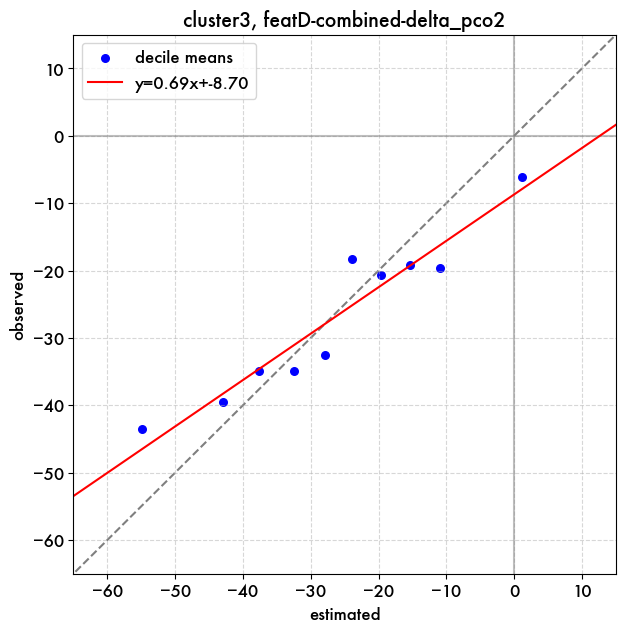

In [33]:
# calibration plot using all folds val errors. do for each run tag 
run_tag = 'featD-combined-delta_pco2'
show_cluster = 3

singleModel_valDF = storedCV_collapsed[run_tag].weighted_validation
singleModel_valDF = singleModel_valDF[singleModel_valDF.cluster==show_cluster]

singleModel_valDF['n_decile'] = pd.qcut(singleModel_valDF['weighted_pred'], 10, labels=list(range(1, 11))) #
cal_pred = singleModel_valDF.groupby('n_decile')['weighted_pred'].agg(['mean', 'min', 'max', 'count'])
cal_obs = singleModel_valDF.groupby('n_decile')['delta_pco2'].agg(['mean', 'min', 'max', 'count'])

stat_var = 'mean'

# === plot 
fig = plt.figure(figsize=(7,7))
ax = fig.gca()

figtitle = ('cluster' + str(show_cluster) + ', ' + run_tag)
figs_reg.plot_decile_calibration(ax, cal_pred, cal_obs, figtitle)


# RECALIBRATED check 
# ax.scatter(singleModel_valDF.lincal_pred, singleModel_valDF.delta_pco2, label='recalibrated', s=5, alpha=0.2, color='r')

# singleModel_valDF['n_decile'] = pd.qcut(singleModel_valDF['lincal_pred'], 10, labels=list(range(1, 11))) #
# cal_pred = singleModel_valDF.groupby('n_decile')['lincal_pred'].agg(['mean', 'min', 'max', 'count'])
# cal_obs = singleModel_valDF.groupby('n_decile')['delta_pco2'].agg(['mean', 'min', 'max', 'count'])

# lincal2 = stats.linregress(cal_pred[stat_var].values, cal_obs[stat_var].values)
# # Plot the fitted line using plt.axline
# ax.axline(xy1=(0, lincal2.intercept), slope=lincal2.slope, color='green', 
#            label=f'y={lincal2.slope:.2f}x+{lincal2.intercept:.2f}', linestyle='-', linewidth=2, zorder=10)




/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_28684/2122251132.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clusterData['n_decile'] = pd.qcut(clusterData['weighted_pred'], 10, labels=list(range(1, 11))) #
/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_28684/2122251132.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clusterData['n_decile'] = pd.qcut(clusterData['weighted_pred'], 10, labels=list(range(1, 11))) #
/var/folders/nt/sjynqxjj7cz9r15fkd5d4r_40000gp/T/ipykernel_2

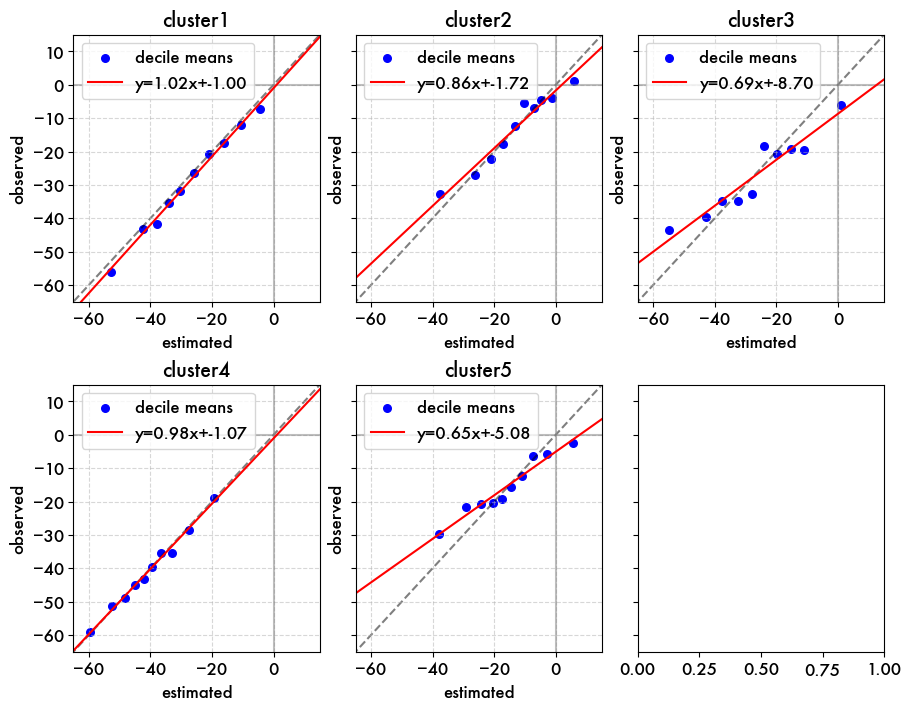

In [36]:
# calibration plot using all folds val errors. do for each run tag 
run_tag = 'featD-combined-delta_pco2'
singleModel_valDF = storedCV_collapsed[run_tag].weighted_validation

# === plot 

fig, axs = plt.subplots(2,3, figsize=(9,7), sharey='row', layout='constrained')

for ind, ax in enumerate(axs.flatten()[:-1]):
    clusterData = singleModel_valDF[singleModel_valDF.cluster==ind+1]

    clusterData['n_decile'] = pd.qcut(clusterData['weighted_pred'], 10, labels=list(range(1, 11))) #
    cal_pred = clusterData.groupby('n_decile', observed=False)['weighted_pred'].agg(['mean', 'min', 'max', 'count'])
    cal_obs = clusterData.groupby('n_decile', observed=False)['delta_pco2'].agg(['mean', 'min', 'max', 'count'])

    figtitle = ('cluster' + str(ind+1) ) # + ', ' + run_tag)
    figs_reg.plot_decile_calibration(ax, cal_pred, cal_obs, figtitle)


In [374]:
print ('intercept, slope')
calcorrections

intercept, slope


{1: [-3.5729225694079076, 0.9555607507541568],
 2: [-1.8355809922910673, 0.9092959957230428],
 3: [-10.967162767796088, 0.6071471867849589],
 4: [-1.520065080784704, 0.9659853995961236],
 5: [-4.754963882712659, 0.6618996534966042]}

In [ ]:
# moved to mod_reg
# def apply_clustered_calibration(cal_coeffs, valDF, n_clusters):
#     """ @param  data_byClass """
#     # Apply the calibration to the weighted prediction 
#     data_byClass = {ncluster:df for ncluster, df in valDF.groupby('cluster')}

#     for ncluster in range(1, n_clusters+1):
#         class_valDF = data_byClass[ncluster].copy()
#         slope, intercept = cal_coeffs[ncluster]

#         # Apply the linear correction to the weighted_pred column
#         class_valDF['lincal_pred'] = class_valDF['weighted_pred'] * slope + intercept
#         data_byClass[ncluster] = class_valDF.copy()
    
#     return data_byClass

# def get_clustered_calibration_coeffs(valDF):
#     cal_coeffs = {ncluster:None for ncluster in valDF['cluster'].unique()}
#     for ncluster, class_valDF in valDF.groupby('cluster'):
#         class_valDF['n_decile'] = pd.qcut(class_valDF['weighted_pred'], 10, labels=list(range(1, 11))) #
#         cal_pred = class_valDF.groupby('n_decile', observed=True)['weighted_pred'].agg(['mean', 'min', 'max', 'count'])
#         cal_obs = class_valDF.groupby('n_decile', observed=True)['delta_pco2'].agg(['mean', 'min', 'max', 'count'])

#         stat_var = 'mean'
#         lincal = stats.linregress(cal_pred[stat_var].values, cal_obs[stat_var].values)

#         cal_coeffs[ncluster] = [lincal.slope, lincal.intercept]
    
#     return cal_coeffs


In [ ]:
# ============== MAIN: Train class dependent calibration 
# Calibrated values stored as "lincal_pred"
# updated feb 6 2026

calcorrections_byRun = {run_tag:None for run_tag in run_tags}

# APPLY CLASS DEPENDENT CORRECTION (to collapsed folds. expand by class)
for run_tag in run_tags:
    singleModel_valDF = storedCV_collapsed[run_tag].weighted_validation
    
    cal_coeffs = mod_reg.get_clustered_calibration_coeffs(singleModel_valDF)
    # Apply the calibration to the weighted prediction
    calibrated_byClass = mod_reg.apply_clustered_calibration(cal_coeffs, singleModel_valDF, n_clusters)

    calcorrections_byRun[run_tag] = cal_coeffs.copy() # store for later
    storedCV_collapsed[run_tag].weighted_validation = pd.concat(calibrated_byClass.values(), axis=0)

In [ ]:
# # (moved to functions in mod_reg) archive: Train class dependent calibration 
# # updated feb 6 2026

# calcorrections_byRun = {run_tag:None for run_tag in run_tags}

# # APPLY CLASS DEPENDENT CORRECTION (to collapsed folds. expand by class)
# for run_tag in run_tags:
#     singleModel_valDF = storedCV_collapsed[run_tag].weighted_validation
#     # For given run, fit the linear regression for each class, store the correction factors
#     # cal_coeffs = {ncluster:None for ncluster in singleModel_valDF['cluster'].unique()}
#     cal_coeffs = get_clustered_calibration_coeffs(singleModel_valDF)

#     # calibrated_error_dict = {ncluster:df for ncluster, df in singleModel_valDF.groupby('cluster')}
#     # This holds validation DF for each class. Will add calibrated columns to these DFs and then recombine at the end
    
#     # for ncluster, class_valDF in singleModel_valDF.groupby('cluster'):
#     #     class_valDF['n_decile'] = pd.qcut(class_valDF['weighted_pred'], 10, labels=list(range(1, 11))) #
#     #     cal_pred = class_valDF.groupby('n_decile', observed=True)['weighted_pred'].agg(['mean', 'min', 'max', 'count'])
#     #     cal_obs = class_valDF.groupby('n_decile', observed=True)['delta_pco2'].agg(['mean', 'min', 'max', 'count'])

#     #     stat_var = 'mean'
#     #     lincal = stats.linregress(cal_pred[stat_var].values, cal_obs[stat_var].values)

#     #     cal_coeffs[ncluster] = [lincal.slope, lincal.intercept]


#     # Apply the calibration to the weighted prediction
#     calibrated_error_dict = apply_clustered_calibration(cal_coeffs, singleModel_valDF, n_clusters)

#     # for ncluster in range(1, n_clusters+1):
#     #     class_valDF = calibrated_error_dict[ncluster].copy()
#     #     slope, intercept = cal_coeffs[ncluster]

#     #     # Apply the linear correction to the weighted_pred column
#     #     class_valDF['lincal_pred'] = class_valDF['weighted_pred'] * slope + intercept
#     #     calibrated_error_dict[ncluster] = class_valDF.copy()
    
#     calcorrections_byRun[run_tag] = cal_coeffs.copy() # store for later
#     storedCV_collapsed[run_tag].weighted_validation = pd.concat(calibrated_error_dict.values(), axis=0)

In [38]:
print('Before calibration')
(mod_reg.storedRuns_comparison(storedCV_collapsed, run_tags[:], param='weighted_pred',
                               show_platforms='float')
                                .sort_values('median_AE')
)

Before calibration


,median_AE,mean_AE,bias,RMSE
featD-combined-delta_pco2,10.886667,14.974859,0.376727,21.013160
featB-combined-delta_pco2,11.304051,15.242426,0.217340,21.213515
featC-combined-delta_pco2,11.414551,15.579657,0.135825,21.631899
featA-combined-delta_pco2,11.809820,15.858994,0.094280,21.830544


In [39]:
print('Linearly calibrated by class')
(mod_reg.storedRuns_comparison(storedCV_collapsed, run_tags[:], param='lincal_pred',
                               show_platforms='float')
                                .sort_values('median_AE')
)

Linearly calibrated by class


,median_AE,mean_AE,bias,RMSE
featD-combined-delta_pco2,10.817927,14.827202,0.000815,20.809211
featB-combined-delta_pco2,11.141972,15.145814,0.000126,21.084491
featC-combined-delta_pco2,11.361554,15.427990,0.000646,21.417361
featA-combined-delta_pco2,11.535837,15.565966,0.000070,21.527112


In [ ]:
# Choose which type of run to show
show_rows = [x for x in run_tags if 'combined' in x]
# show_rows = storedRuns_summary.index.tolist()

# Choose order
storedRuns_summary.loc[show_rows]
storedRuns_summary.loc[show_rows].sort_values('median_AE')

In [ ]:
# Choose which type of run to show
show_rows = [x for x in run_tags if 'combined' in x]
# show_rows = storedRuns_summary.index.tolist()

# Choose order
storedRuns_summary.loc[show_rows]
storedRuns_summary.loc[show_rows].sort_values('median_AE')

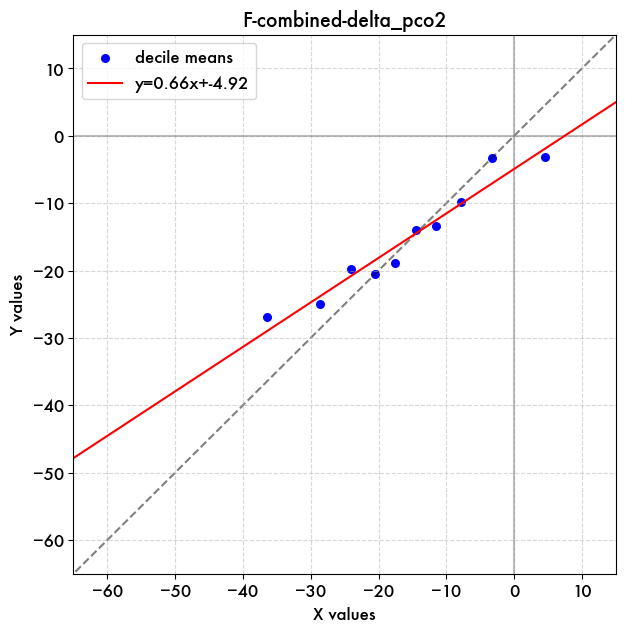

In [320]:

# === example plot 
fig = plt.figure(figsize=(7,7))
ax = fig.gca()

figs_reg.plot_decile_calibration(ax, cal_pred, cal_obs, run_tag)
# figs_reg.plot_decile_calibration(ax, class_valDF, run_tag)

from scipy import stats

lincal = stats.linregress(cal_pred[stat_var].values, cal_obs[stat_var].values)

# Create the scatter plot
# plt.plot(cal_pred, cal_obs)

# Plot the fitted line using plt.axline
plt.axline(xy1=(0, lincal.intercept), slope=lincal.slope, color='r', 
           label=f'y={lincal.slope:.2f}x+{lincal.intercept:.2f}')

# Add labels, a legend, and show the plot
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.show()

In [256]:
storedCV_collapsed[run_tag].weighted_validation

,profid,wmoid,prof_datetag,cluster,datetime,latitude,longitude,linear_time,ydcos,ydsin,...,class4_pred,class5_pred,weighted_pred,val_error,val_relative_error,fold,val_error_sq,ape,n_decile,lincal_pred
2842,5904675_id021,5904675.0,5904675_20160807,1,2016-08-07 05:21:59.999995,-41.379000,95.86900,949.223611,-0.813307,-0.581835,...,-18.329190,-33.805399,-24.507969,-13.492654,1.224899,fold1,182.051703,122.489942,5,-26.617289
2843,5904675_id022,5904675.0,5904675_20160817,1,2016-08-17 13:21:59.999998,-41.282000,95.47600,959.556944,-0.697609,-0.716479,...,-19.264839,-34.320548,-22.139719,-20.505480,12.547417,fold1,420.474720,1254.741674,6,-24.370219
2844,5904675_id023,5904675.0,5904675_20160827,1,2016-08-27 21:39:59.999998,-41.115000,95.05200,969.902778,-0.559747,-0.828663,...,-19.084029,-33.360020,-21.335254,-17.025193,3.950105,fold1,289.857205,395.010524,6,-23.606916
2845,5904675_id024,5904675.0,5904675_20160907,1,2016-09-07 05:59:00.000004,-40.963000,94.44500,980.249306,-0.404192,-0.914674,...,-21.835863,-32.126673,-15.208105,-11.564063,3.173417,fold1,133.727561,317.341704,7,-17.793283
2846,5904675_id025,5904675.0,5904675_20160917,1,2016-09-17 14:11:00.000004,-40.803000,93.75300,990.590972,-0.235948,-0.971766,...,-20.823235,-31.514912,-12.862336,-16.517481,-4.518968,fold1,272.827167,451.896816,8,-15.567543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6056,NaN,NaN,NaN,5,2022-07-26 13:17:00,-48.912000,0.11250,3128.553472,-0.916471,-0.400102,...,-10.603605,-17.150846,-3.282662,-45.066862,-1.078562,fold5,2031.022040,107.856227,9,-7.084860
6067,NaN,NaN,NaN,5,2023-01-30 12:02:01,-48.657590,102.74320,3316.501400,0.876046,0.482227,...,-16.077272,-19.447932,-19.424051,-5.140145,0.359856,fold5,26.421095,35.985573,6,-17.744363
6068,NaN,NaN,NaN,5,2023-01-31 12:13:56,-51.750025,99.28497,3317.509676,0.867551,0.497348,...,-17.046735,-13.274981,-13.313137,9.981110,-0.428480,fold5,99.622547,42.847960,8,-13.708818
6069,NaN,NaN,NaN,5,2023-02-17 12:07:05,-50.625600,102.04070,3334.504919,0.687396,0.726283,...,-14.196767,-25.641185,-25.636527,-10.048162,0.644594,fold5,100.965560,64.459369,5,-21.846978


# Fit new RF with all available data

- Fit new random forest with combined ship, float data and chosen run tag
- Make sure to exclude appropriate classes and rename labels for core Argo floats 
- Use calibration coefficients from cross-validation step

In [541]:
# # calcorrections_byRun holds final linear calibration
# use_calibration_coeffs = calcorrections_byRun[run_tag] # dictionary keyed by cluster
# use_calibration_coeffs # (slope, intercept)

{1: [0.9488317632233807, -3.3633495608219874],
 2: [0.9207152232533948, -1.3655454387309494],
 3: [0.49991961773371546, -13.683158984970914],
 4: [0.962123242169694, -1.7418124121533012],
 5: [0.6603832153207686, -4.917045219285754]}

In [99]:
all_data

,profid,wmoid,prof_datetag,cluster,datetime,latitude,longitude,linear_time,ydcos,ydsin,...,sampleid,cruiseid,nearest_profid,atm_pres_hPa,fco2rec,class1_prob,class2_prob,class3_prob,class4_prob,class5_prob
152,5904187_id030,5904187.0,5904187_20140919,1,2014-09-19 03:50:59.999999,-44.103000,205.27400,261.160417,-0.218031,-0.975942,...,NaN,NaN,NaN,NaN,NaN,5.093413e-01,3.858982e-49,0.025120,6.837408e-05,0.465470
160,5904187_id038,5904187.0,5904187_20141031,1,2014-10-31 12:36:00.000002,-43.861000,202.24800,303.525000,0.487284,-0.873244,...,NaN,NaN,NaN,NaN,NaN,5.481610e-01,2.336125e-51,0.033062,9.771319e-05,0.418679
1016,5904188_id002,5904188.0,5904188_20140420,1,2014-04-20 13:16:00.000000,-49.675000,211.30700,109.552778,-0.308653,0.951175,...,NaN,NaN,NaN,NaN,NaN,7.463596e-01,3.338226e-56,0.070568,2.848177e-04,0.182788
1018,5904188_id004,5904188.0,5904188_20140501,1,2014-05-01 04:07:59.999998,-50.992000,212.63100,120.172222,-0.476313,0.879276,...,NaN,NaN,NaN,NaN,NaN,5.771468e-01,2.385439e-53,0.095094,2.186775e-04,0.327541
1022,5904188_id008,5904188.0,5904188_20140522,1,2014-05-22 09:20:59.999995,-52.008000,217.17400,141.389583,-0.758786,0.651340,...,NaN,NaN,NaN,NaN,NaN,5.204696e-01,8.835796e-52,0.013211,4.796229e-05,0.466271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6060,NaN,NaN,NaN,5,2023-03-19 12:21:59,-52.162815,-147.83595,3364.515266,0.239302,0.970945,...,69920230226_id4,69920230226,5905329_id198,101020.0,417.0975,3.213754e-08,2.419410e-24,0.048526,1.340475e-07,0.951474
6061,NaN,NaN,NaN,5,2023-03-20 12:21:59,-50.943240,-136.44575,3365.515266,0.222564,0.974918,...,69920230226_id4,69920230226,5904802_id230,102570.0,414.2835,3.713597e-03,3.805514e-42,0.021198,4.919045e-06,0.975084
6062,NaN,NaN,NaN,5,2023-03-21 10:57:29,-48.602290,-126.32730,3366.456586,0.206749,0.978394,...,69920230226_id4,69920230226,5904797_id232,102830.0,421.4130,1.216263e-04,1.045477e-32,0.001054,8.872336e-08,0.998824
6077,NaN,NaN,NaN,5,2023-01-17 05:47:16,-50.672020,175.27430,3303.241157,0.962402,0.271630,...,61TG20230115_id1,61TG20230115,5906254_id086,100000.0,408.1340,1.591810e-08,2.235934e-13,0.012879,8.594398e-09,0.987121


In [42]:
# All available data is represented by data in one fold 

run_tag = 'featD-combined-delta_pco2'
all_data = pd.concat([cvtainer_final.trainDF_all['fold1'], cvtainer_final.valDF_all['fold1']], axis=0)

final_training = {k:v for k, v in all_data.groupby('cluster')}
final_training[1]

,profid,wmoid,prof_datetag,cluster,datetime,latitude,longitude,linear_time,ydcos,ydsin,...,sampleid,cruiseid,nearest_profid,atm_pres_hPa,fco2rec,class1_prob,class2_prob,class3_prob,class4_prob,class5_prob
152,5904187_id030,5904187.0,5904187_20140919,1,2014-09-19 03:50:59.999999,-44.103000,205.27400,261.160417,-0.218031,-0.975942,...,NaN,NaN,NaN,NaN,NaN,0.509341,3.858982e-49,0.025120,0.000068,4.654703e-01
160,5904187_id038,5904187.0,5904187_20141031,1,2014-10-31 12:36:00.000002,-43.861000,202.24800,303.525000,0.487284,-0.873244,...,NaN,NaN,NaN,NaN,NaN,0.548161,2.336125e-51,0.033062,0.000098,4.186791e-01
1016,5904188_id002,5904188.0,5904188_20140420,1,2014-04-20 13:16:00.000000,-49.675000,211.30700,109.552778,-0.308653,0.951175,...,NaN,NaN,NaN,NaN,NaN,0.746360,3.338226e-56,0.070568,0.000285,1.827880e-01
1018,5904188_id004,5904188.0,5904188_20140501,1,2014-05-01 04:07:59.999998,-50.992000,212.63100,120.172222,-0.476313,0.879276,...,NaN,NaN,NaN,NaN,NaN,0.577147,2.385439e-53,0.095094,0.000219,3.275407e-01
1022,5904188_id008,5904188.0,5904188_20140522,1,2014-05-22 09:20:59.999995,-52.008000,217.17400,141.389583,-0.758786,0.651340,...,NaN,NaN,NaN,NaN,NaN,0.520470,8.835796e-52,0.013211,0.000048,4.662711e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031,NaN,NaN,NaN,1,2022-08-18 09:19:29,-42.076635,175.05610,3151.388530,-0.693510,-0.720447,...,PANC20220804_id3,PANC20220804,5902393_id279,102380.0,381.2960,0.973970,2.543373e-85,0.019819,0.006050,1.607429e-04
2032,NaN,NaN,NaN,1,2023-03-11 12:21:59,-46.788020,122.29075,3356.515266,0.370239,0.928937,...,69920230226_id4,69920230226,6902758_id219,100260.0,411.9655,0.999077,1.747838e-87,0.000382,0.000542,4.653839e-09
2033,NaN,NaN,NaN,1,2023-03-12 12:21:59,-47.958830,136.36900,3357.515266,0.354205,0.935168,...,69920230226_id4,69920230226,5905398_id181,101330.0,422.7240,0.997990,1.837562e-93,0.000673,0.001336,6.626892e-10
2034,NaN,NaN,NaN,1,2023-03-13 12:21:59,-48.920620,147.22610,3358.515266,0.338066,0.941122,...,69920230226_id4,69920230226,5906623_id264,100850.0,392.7155,0.991249,7.247551e-69,0.008386,0.000308,5.663070e-05


In [43]:
# Train final model 
run_tag = 'featD-combined-delta_pco2'
all_data = pd.concat([cvtainer_final.trainDF_all['fold1'], cvtainer_final.valDF_all['fold1']], axis=0)
final_training = {k:v for k, v in all_data.groupby('cluster')}

# Use master run list
feat_key = run_tag.split('-')[0]
dataset_key = run_tag.split('-')[1]
var_predict = run_tag.split('-')[2]

nclusters = n_gmm - len(exclude_nums)
k_list = range(1,nclusters+1) # Number of clusters
feat_list = feat_options[feat_key]

RFR_final = mod_reg.ClusteredModelVersion(ind_list = k_list, feat_list = feat_list) #singleRun

# === TRAINING
for k in k_list: 
    trainingDF_class = final_training[k] 
    RFR_final.models[k] = mod_reg.fit_single_RFR(feat_list, 
                            trainingDF_class, 
                            var_predict = var_predict, 
                            loss_criterion = 'squared_error',
                            ntrees = ntrees, max_feats = max_feats,
                            min_samples_split=min_samples_split)

# === NEW VALIDATION ERRORS
trainDF_allclasses = pd.concat(final_training.values())
RFR_final.weighted_training = mod_reg.apply_cluster_RFR(feat_list, RFR_final, trainDF_allclasses, sample_tag='train')

In [44]:
feat_list

['CT', 'SA', 'mld', 'adt', 'ydcos', 'ydsin']

# Test on 2024 bgc-Argo data

# Apply to core Argo

In [45]:
# should eventually use loader.import_clustered_data 
filepath = '../working-vars/pcm/' + pcm_params + '/'

coreINDEX_clustered = xr.open_dataset(filepath + 'coreINDEX_classified_' + '20260119' + '.nc')
[coreDS, coreINDEX] = loader.import_core_data(type='processed')


In [68]:
coreINDEX

<xarray.Dataset>
Dimensions:      (profid: 328938)
Coordinates:
  * profid       (profid) object '1900410_id260' ... '7901011_id005'
    latitude     (profid) float64 ...
    longitude    (profid) float64 ...
    datetime     (profid) object ...
    yearday      (profid) float64 ...
Data variables: (12/15)
    pressure     (profid) float64 ...
    wmoid        (profid) float64 ...
    CT           (profid) float64 ...
    SA           (profid) float64 ...
    sigma0       (profid) float64 ...
    spice        (profid) float64 ...
    ...           ...
    position_qc  (profid) float64 ...
    bathymetry   (profid) float64 ...
    mld          (profid) float64 ...
    adt          (profid) float64 ...
    ydcos        (profid) float64 ...
    ydsin        (profid) float64 ...
Attributes:
    title:    Core profiles with valid QC data, masked to open ocean bathymet...

In [70]:
foo = coreINDEX.to_dataframe()
foo['datetime'] = foo['datetime'].astype('datetime64[ns]')
# coreDF_delta_pco2 = mod_prep.add_regression_vars(foo)

foo['linear_time'] = foo.datetime.apply(lambda x: mod_ocean.datetime2ytd(np.datetime64(x), ref_time='2014-01-01'))
foo['ydcos']= mod_ocean.get_ydsines(foo.linear_time.values)[0]
foo['ydsin']= mod_ocean.get_ydsines(foo.linear_time.values)[1]
foo = mod_ocean.add_decimalyr(foo)

# Get atmospheric fco2 from MBL marine boundary layer product
# make target delta pco2 variable
foo['sin_lat'] = np.sin(foo['latitude']*np.pi/180)
foo['pco2_atm'] = foo.apply(mod_prep.get_row_pco2_atm, axis=1)

/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/src/mod_ocean.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (df['datetime'].dt.is_leap_year.replace({True: 366, False: 365}))


In [71]:
coreINDEX_with_pco2atmos = xr.Dataset.from_dataframe(foo)

In [74]:
coreINDEX_with_pco2atmos

savepath = '../working-vars/regression/inputs/core/'
coreINDEX_with_pco2atmos.to_netcdf(savepath + 'coreINDEX_pco2-atmos_processed_2014-2023_MLD_ADT_acc' + datetag + '.nc')
print('Saved to ' + savepath + 'coreINDEX_pco2-atmos_processed_2014-2023_MLD_ADT_acc' + datetag + '.nc')
print(datetime.now().strftime('%Y-%m-%d, %H:%M:%S') )

Saved to ../working-vars/regression/inputs/core/coreINDEX_pco2-atmos_processed_2014-2023_MLD_ADT_acc20260210.nc
2026-02-10, 10:16:24


In [516]:
# coreINDEX
# # add ADT 
# # finder = coreDS.sel(profid=[x for x in coreINDEX_clustered.profid.values], pressure=15)
# finder = (coreDS.sel(profid=[x for x in coreINDEX_clustered.profid.values], pressure=15)
#                 .reset_coords(['longitude', 'latitude', 'datetime', 'yearday', 'pressure']))
# coreINDEX['adt'] = finder['adt']
# coreINDEX['ydcos'] = finder['ydcos']
# coreINDEX['ydsin'] = finder['ydsin']

# # folder = '../working-vars/regression/inputs/core/'
# # filename = 'coreINDEX_processed_2014-2023_MLD_ADT_acc' + datetag + '.nc'
# # coreINDEX.to_netcdf(folder + filename)
# coreINDEX


<xarray.Dataset>
Dimensions:      (profid: 328938)
Coordinates:
  * profid       (profid) object '1900410_id260' ... '7901011_id005'
Data variables: (12/19)
    pressure     (profid) float64 ...
    wmoid        (profid) float64 ...
    latitude     (profid) float64 ...
    longitude    (profid) float64 ...
    datetime     (profid) object ...
    yearday      (profid) float64 ...
    ...           ...
    position_qc  (profid) float64 ...
    bathymetry   (profid) float64 ...
    mld          (profid) float64 90.55 66.09 13.02 74.86 ... 82.53 71.18 19.52
    adt          (profid) float64 0.5323 0.5553 0.6055 ... -0.4765 -0.5156
    ydcos        (profid) float64 0.9998 0.9813 0.9327 ... 0.8784 0.946 0.987
    ydsin        (profid) float64 0.01904 0.1927 0.3605 ... -0.3241 -0.1608
Attributes:
    title:    Core profiles with valid QC data, masked to open ocean bathymet...

In [46]:
# =======  Prepare core argo data (~2 min run time)
# First add mld, adt to the clustered core data
finder = (coreINDEX.sel(profid=[x for x in coreINDEX_clustered.profid.values])
          .reset_coords(['longitude', 'latitude', 'datetime', 'yearday', 'pressure']))   
for var in ['mld', 'adt', 'ydcos', 'ydsin']:
    coreINDEX_clustered[var] = finder[var]

# Rename keys starting from 1 instead of 0 (expected after 1.2)
core_classes_ds = {int(k):dat for k, dat in coreINDEX_clustered.groupby('class')}
if list(core_classes_ds.keys())[0] == 0:
    core_classes_ds = {k+1:dat for k, dat in core_classes_ds.items()}

# Convert to dataframes and change class numbers after excluding classes
core_classes_df = {ncluster:None for ncluster in range(1,n_clusters+1)}
for k, v in tqdm(core_classes_ds.items()):
    core_classes_df[k] = v.to_dataframe()

[fin_trainClasses, fin_trainDF_all] = mod_reg.exclude_classes(exclude_nums, core_classes_df, n_gmm=n_gmm, reassign_numbers=True)

100%|██████████| 6/6 [01:57<00:00, 19.66s/it]


In [47]:
# === Apply the trained RFR to the core data, get weighted predictions for each cluster
print('==> Applying final RFR ' + run_tag + '; ' + datetime.now().strftime('%Y-%m-%d %H:%M:%S') )
coreDF_weighted_preds = mod_reg.apply_cluster_RFR(feat_list, RFR_final, fin_trainDF_all, sample_tag='core', target_known=False)

==> Applying final RFR featD-combined-delta_pco2; 2026-02-10 09:26:14


In [48]:
# Use linear calibration coeffs found earlier
use_calibration_coeffs = calcorrections_byRun[run_tag] # dictionary keyed by cluster
use_calibration_coeffs # (slope, intercept)


calibrated_byClass = mod_reg.apply_clustered_calibration(use_calibration_coeffs, coreDF_weighted_preds, n_clusters)
coreDF_calibrated_preds = pd.concat(calibrated_byClass.values(), axis=0)

In [63]:
import mod_ocean

In [64]:
# Add atmospheric pco2, add back to delta_pco2 predicted to get to surface seawater pco2 
coreDF_calibrated_preds['delta_pco2'] = coreDF_calibrated_preds['lincal_pred']

coreDF_calibrated_preds['datetime'] = coreDF_calibrated_preds['datetime'].astype('datetime64[ns]')
# coreDF_delta_pco2 = mod_prep.add_regression_vars(coreDF_calibrated_preds)

coreDF_calibrated_preds['linear_time'] = coreDF_calibrated_preds.datetime.apply(lambda x: mod_ocean.datetime2ytd(np.datetime64(x), ref_time='2014-01-01'))
coreDF_calibrated_preds['ydcos']= mod_ocean.get_ydsines(coreDF_calibrated_preds.linear_time.values)[0]
coreDF_calibrated_preds['ydsin']= mod_ocean.get_ydsines(coreDF_calibrated_preds.linear_time.values)[1]
coreDF_calibrated_preds = mod_ocean.add_decimalyr(coreDF_calibrated_preds)

# Get atmospheric fco2 from MBL marine boundary layer product
# make target delta pco2 variable
coreDF_calibrated_preds['sin_lat'] = np.sin(coreDF_calibrated_preds['latitude']*np.pi/180)
coreDF_calibrated_preds['pco2_atm'] = coreDF_calibrated_preds.apply(mod_prep.get_row_pco2_atm, axis=1)



/Users/sangminsong/Library/CloudStorage/OneDrive-UW/Code/CRUSOE/src/mod_ocean.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (df['datetime'].dt.is_leap_year.replace({True: 366, False: 365}))


In [66]:
coreDF_calibrated_preds['pco2_ocean'] = coreDF_calibrated_preds['delta_pco2'] + coreDF_calibrated_preds['pco2_atm'] 

In [67]:
savepath = '../working-vars/regression/predictions/'
save = True

if save:
    new_attrs = {'linear_calibration_coeffs' : str(use_calibration_coeffs)[1:-1],
                'pcm_params': pcm_params,
                'features' : feat_list,
                'run_date' : datetime.now().strftime('%Y-%m-%d, %H:%M:%S')
                }
    coreDS_calibrated_preds = coreDF_calibrated_preds.to_xarray().assign_attrs(new_attrs)
    coreDS_calibrated_preds.to_netcdf(savepath + 'coreDS_delta_calibrated_preds_' + run_tag + '_' + datetag + '.nc')
    print('Saved to ' + savepath + 'coreDS_delta_calibrated_preds_' + run_tag + '_' + datetag + '.nc')
    print(datetime.now().strftime('%Y-%m-%d, %H:%M:%S') )

Saved to ../working-vars/regression/predictions/coreDS_delta_calibrated_preds_featD-combined-delta_pco2_20260210.nc
2026-02-10, 09:50:13


In [ ]:
# savepath = '../working-vars/regression/predictions/'
# coreDF_calibrated_preds.to_csv(savepath + 'coreDF_calibrated_preds_' + pcm_params + run_tag + '_' + datetag + '.csv')

In [77]:
coreDS_calibrated_preds.lincal_pred.to_dataframe().describe()

,lincal_pred
count,275143.000000
mean,-24.256701
std,15.356349
min,-90.413025
25%,-35.599487
50%,-22.953365
75%,-12.352106
max,25.645420


In [78]:
275143 + 17000

292143

In [ ]:
# all_data from above
[floatsave, shipsave] = mod_reg.separate_platforms(all_data)
shipsave['platform'] = np.tile('socatv2024', len(shipsave))
floatsave['platform'] = np.tile('bgc', len(floatsave))

shipsave['pco2_ocean']
floatsave['pco2_ocean'] = floatsave['pCO2_pHbias5_pK1'].copy()

In [113]:
shipsave.columns

Index(['profid', 'wmoid', 'prof_datetag', 'cluster', 'datetime', 'latitude',
       'longitude', 'linear_time', 'ydcos', 'ydsin', 'decimalyr', 'CT', 'SA',
       'mld', 'pCO2_standard', 'pCO2_pHbias3', 'pCO2_pHbias5',
       'pCO2_pHbias3_pK1', 'pCO2_pHbias5_pK1', 'pco2', 'pco2_atm',
       'delta_pco2', 'year', 'month', 'day', 'adt', 'sla', 'sampleid',
       'cruiseid', 'nearest_profid', 'atm_pres_hPa', 'fco2rec', 'class1_prob',
       'class2_prob', 'class3_prob', 'class4_prob', 'class5_prob', 'platform'],
      dtype='object')

In [ ]:
coresave = coreDS_calibrated_preds.to_dataframe().reset_index()
coresave['platform'] = np.tile('core', len(coresave))

In [86]:
coresave['platform'] = np.tile('core', len(coresave))

In [105]:
newsave = pd.concat([shipsave, floatsave], axis=0)
newsave.head()

,profid,wmoid,prof_datetag,cluster,datetime,latitude,longitude,linear_time,ydcos,ydsin,...,cruiseid,nearest_profid,atm_pres_hPa,fco2rec,class1_prob,class2_prob,class3_prob,class4_prob,class5_prob,platform
0,NaN,NaN,NaN,1,2014-01-31 11:31:33,-48.276570,140.3490,30.480243,0.865658,0.500637,...,09AR20140129,5903811_id084,99660.0,345.050,0.913455,1.975964e-108,0.010398,0.076147,1.956080e-11,socatv2024
1,NaN,NaN,NaN,1,2014-02-27 12:08:46,-46.564480,138.9087,57.506088,0.549322,0.835611,...,09AR20140129,5903631_id127,101480.0,324.382,0.862893,4.050870e-155,0.000193,0.136915,7.924437e-10,socatv2024
2,NaN,NaN,NaN,1,2014-02-28 10:15:15,-44.422840,145.0141,58.427257,0.536012,0.844210,...,09AR20140129,1901406_id149,101990.0,334.735,0.966401,1.289943e-137,0.000356,0.033243,3.514727e-10,socatv2024
3,NaN,NaN,NaN,1,2014-03-10 12:19:07,-47.839280,144.0506,68.513275,0.382224,0.924070,...,09AR20140309,5903226_id160,101620.0,361.239,0.888418,1.640060e-82,0.084950,0.026632,1.396552e-10,socatv2024
4,NaN,NaN,NaN,1,2014-04-17 11:44:53,-47.322995,134.9511,106.489502,-0.258125,0.966111,...,09AR20140309,1901436_id156,100980.0,361.286,0.997618,4.886668e-71,0.002055,0.000162,1.647310e-04,socatv2024


In [110]:
# newsave.columns
use_cols = ['latitude', 'longitude', 'datetime', 
 'pco2_atm', 'pco2_ocean', 
 'platform', 'profid', 'wmoid', 'cruiseid', 'sampleid']

# 'cluster', 'profid', 'prof_datetag', 'wmoid', 
# 'sampleid', 'cruiseid', 'nearest_profid',
# 'pressure', 'sigma0', 'spice', 'mld', 'adt', 
# 'CT', 'SA', 'temperature', 'salinity',
# 'class1_prob', 'class2_prob', 'class3_prob', 'class4_prob', 'class5_prob', 
# 'class1_pred', 'class2_pred', 'class3_pred', 'class4_pred', 'class5_pred',
# 'lincal_pred', 'weighted_pred', 'delta_pco2', 
# 'platform']

newsave[use_cols]

KeyError: "['pco2_ocean'] not in index"

In [89]:
# with core
#  ['latitude', 'longitude', 'datetime', 
#  'lincal_pred', 'weighted_pred', 'delta_pco2', 
#  'cluster', 
    
#     'profid', 'pressure', 'wmoid', 'latitude', 'longitude', 'datetime',
#        'yearday', 'CT', 'SA', 'sigma0', 'spice', 'temperature', 'salinity',
#        'time_qc', 'position_qc', 'bathymetry', 'class', 'mld', 'adt', 'ydcos',
#        'ydsin', 'class1_prob', 'class2_prob', 'class3_prob', 'class4_prob',
#        'class5_prob', 
#        'class1_pred', 'class2_pred', 'class3_pred', 'class4_pred', 'class5_pred', 
       

#        'sin_lat', 'pco2_atm', 'pco2_ocean', 'platform', 'prof_datetag',
#        'pCO2_standard', 'pCO2_pHbias3', 'pCO2_pHbias5', 'pCO2_pHbias3_pK1',
#        'pCO2_pHbias5_pK1', 'year', 'month', 'day', 'sla', 'sampleid',
#        'cruiseid', 'nearest_profid', 'atm_pres_hPa', 'fco2rec']

Index(['profid', 'pressure', 'wmoid', 'latitude', 'longitude', 'datetime',
       'yearday', 'CT', 'SA', 'sigma0', 'spice', 'temperature', 'salinity',
       'time_qc', 'position_qc', 'bathymetry', 'class', 'mld', 'adt', 'ydcos',
       'ydsin', 'class1_prob', 'class2_prob', 'class3_prob', 'class4_prob',
       'class5_prob', 'cluster', 'log_mld', 'class1_pred', 'class2_pred',
       'class3_pred', 'class4_pred', 'class5_pred', 'weighted_pred',
       'lincal_pred', 'pco2', 'linear_time', 'delta_pco2', 'decimalyr',
       'sin_lat', 'pco2_atm', 'pco2_ocean', 'platform', 'sampleid', 'cruiseid',
       'nearest_profid', 'atm_pres_hPa', 'fco2rec', 'year', 'month', 'day',
       'sla', 'class6_prob', 'prof_datetag', 'pCO2_standard', 'pCO2_pHbias3',
       'pCO2_pHbias5', 'pCO2_pHbias3_pK1', 'pCO2_pHbias5_pK1'],
      dtype='object')

In [ ]:
['profid', 'pressure', 'wmoid', 'latitude', 'longitude', 'datetime',
       'yearday', 'CT', 'SA', 'sigma0', 'spice', 'temperature', 'salinity',
       'time_qc', 'position_qc', 'bathymetry', 'class', 'mld', 'adt', 'ydcos',
       'ydsin', 'class1_prob', 'class2_prob', 'class3_prob', 'class4_prob',
       'class5_prob', 'cluster', 'log_mld', 'class1_pred', 'class2_pred',
       'class3_pred', 'class4_pred', 'class5_pred', 'weighted_pred',
       'lincal_pred', 'pco2', 'linear_time', 'delta_pco2', 'decimalyr',
       'sin_lat', 'pco2_atm', 'pco2_ocean', 'platform', 'sampleid', 'cruiseid',
       'nearest_profid', 'atm_pres_hPa', 'fco2rec', 'year', 'month', 'day',
       'sla', 'class6_prob', 'prof_datetag', 'pCO2_standard', 'pCO2_pHbias3',
       'pCO2_pHbias5', 'pCO2_pHbias3_pK1', 'pCO2_pHbias5_pK1']